MSE 446 Project - Team 2

In [2]:
import pandas as pd

In [3]:
# Read song datasets
songs_popular = pd.read_csv('datasets/high_popularity_spotify_data.csv')
songs_notpopular = pd.read_csv('datasets/low_popularity_spotify_data.csv')

# artist popularity dataset
artist_popularity = pd.read_csv('datasets/spotify_data_artists.csv')

# combine low popularity and high popularity songs into one dataset
songs = pd.concat([songs_popular, songs_notpopular], ignore_index=True)


In [4]:
songs['track_id'].nunique()

4495

In [5]:

# Prepare artist dataset
artist_popularity = artist_popularity.rename(columns={
    'name': 'artist_name',
    'popularity': 'artist_popularity'
})

# Normalize artist names
artist_popularity['artist_name'] = artist_popularity['artist_name'].str.lower().str.strip()

# Create lookup dictionary
artist_top_track_popularity = dict(zip(
    artist_popularity['artist_name'],
    artist_popularity['artist_popularity']
))

# Function to find first matching artist
def get_artist_popularity(artist_string):
    if pd.isna(artist_string):
        return None
    
    artists = [a.strip().lower() for a in artist_string.split(',')]
    
    for artist in artists:
        if artist in artist_top_track_popularity:
            return artist_top_track_popularity[artist]
    
    return None  # no match found

# Apply function to get the artist popularity from the second dataset
songs['artist_popularity'] = songs['track_artist'].apply(get_artist_popularity)

In [6]:
# Build artist -> max track popularity dictionary
artist_top_track_popularity = {}

for _, row in songs.iterrows():
    artists = [a.strip() for a in row["track_artist"].split(",")]
    
    for artist in artists:
        current_pop = row["track_popularity"]
        
        if artist not in artist_top_track_popularity:
            artist_top_track_popularity[artist] = current_pop
        else:
            artist_top_track_popularity[artist] = max(artist_top_track_popularity[artist], current_pop)

print(artist_top_track_popularity)


# Step 2: Function to get the top popularity among the artists of a song
def get_top_popularity(artists):
    artist_list = [a.strip() for a in artists.split(",")]
    pops = [artist_top_track_popularity.get(a, 0) for a in artist_list]
    return max(pops)


# Step 3: Apply to dataframe
songs["artist_top_track_popularity"] = songs["track_artist"].apply(get_top_popularity)

{'Lady Gaga': 100, 'Bruno Mars': 100, 'Billie Eilish': 97, 'Gracie Abrams': 93, 'Sabrina Carpenter': 93, 'ROSÉ': 98, 'Chappell Roan': 94, 'Addison Rae': 88, 'Gigi Perez': 93, 'The Weeknd': 92, 'Playboi Carti': 92, 'Charli xcx': 85, 'Tate McRae': 79, 'Shaboozey': 86, 'LISA': 85, 'Morgan Wallen': 86, 'Adam Port': 86, 'Stryv': 86, 'Keinemusik': 86, 'Orso': 86, 'Malachiii': 86, 'Tyler': 90, 'The Creator': 90, 'GloRilla': 88, 'Sexyy Red': 88, 'Lil Wayne': 88, 'JENNIE': 89, 'Rauw Alejandro': 82, 'Bad Bunny': 84, 'Don Toliver': 85, 'Post Malone': 84, 'Hozier': 84, 'The Marías': 84, 'Oscar Maydon': 93, 'Fuerza Regida': 93, 'Myles Smith': 88, 'Ariana Grande': 86, 'Benson Boone': 89, 'Myke Towers': 84, 'benny blanco': 84, 'KATSEYE': 85, 'Teddy Swims': 89, 'Mark Ambor': 82, 'KAROL G': 93, 'Djo': 89, 'Taylor Swift': 84, 'Omar Courtz': 89, 'De La Rose': 89, 'Kendrick Lamar': 88, 'Jin': 85, 'Feid': 88, 'DFZM': 84, 'Ovy On The Drums': 84, 'J Balvin': 84, 'Maluma': 84, 'Ryan Castro': 84, 'Blessd': 84,

In [7]:
songs.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,artist_popularity,artist_top_track_popularity
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,88.0,100
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,90.0,97
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,82.0,93
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,91.0,93
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,78.0,100


In [8]:
songs.info()

<class 'pandas.DataFrame'>
RangeIndex: 4831 entries, 0 to 4830
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   energy                       4830 non-null   float64
 1   tempo                        4830 non-null   float64
 2   danceability                 4830 non-null   float64
 3   playlist_genre               4831 non-null   str    
 4   loudness                     4830 non-null   float64
 5   liveness                     4830 non-null   float64
 6   valence                      4830 non-null   float64
 7   track_artist                 4831 non-null   str    
 8   time_signature               4830 non-null   float64
 9   speechiness                  4830 non-null   float64
 10  track_popularity             4831 non-null   int64  
 11  track_href                   4830 non-null   str    
 12  uri                          4830 non-null   str    
 13  track_album_name             

Max: 100.0
Min: 0.0


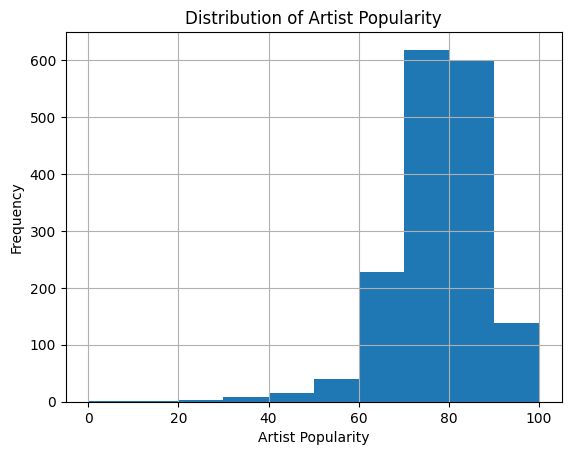

In [9]:
max_val = songs['artist_popularity'].max()
min_val = songs['artist_popularity'].min()

print("Max:", max_val)
print("Min:", min_val)

import matplotlib.pyplot as plt

songs['artist_popularity'].hist()
plt.xlabel('Artist Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Artist Popularity')
plt.show()

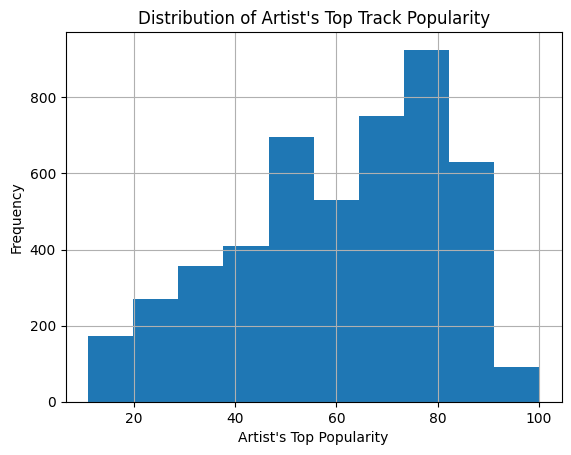

In [10]:
songs['artist_top_track_popularity'].hist()
plt.xlabel('Artist\'s Top Popularity')
plt.ylabel('Frequency')
plt.title('Distribution of Artist\'s Top Track Popularity')
plt.show()

In [11]:
songs['playlist_subgenre'].value_counts()

playlist_subgenre
modern         695
chill          420
classic        293
meditative     231
french         161
              ... 
noir             8
irish            6
heavy            5
avant-garde      2
post-rock        2
Name: count, Length: 84, dtype: int64

In [12]:
## Clean data

In [13]:
## Clean data
pd.set_option('display.max_columns', None)

# Count of duplicated rows
songs.duplicated().sum()

# Drop duplicated rows
songs.drop_duplicates()

# Duplicated tracks
songs['track_id'].duplicated()

# We can see that there are duplicate tracks with identical rows except the playlist subgenre. 
songs[songs['track_id'].duplicated(keep=False)].sort_values('track_id')
dupes = songs[songs['track_id'].duplicated(keep=False)]
dupes.groupby('track_id').nunique()

diff_cols = dupes.groupby('track_id').nunique()
diff_cols.loc[:, (diff_cols > 1).any()]

# Here we can see that the only columns that differ are playlist_genre, playlist_name, playlist_subgenre, playlist_id. We will combine them 
# to deal with the duplicated song ids. 
cols_to_combine = [
    'playlist_genre',
    'playlist_name',
    'playlist_subgenre',
    'playlist_id'
]

agg_dict = {col: lambda x: ', '.join(sorted(set(x))) for col in cols_to_combine}

# keep other columns
for col in songs.columns:
    if col not in cols_to_combine and col != 'track_id':
        agg_dict[col] = 'first'

songs = songs.groupby('track_id', as_index=False).agg(agg_dict)

songs['track_id'].nunique()

4495

In [14]:
## Deal with missing values
songs.isna().sum().sort_values(ascending=False)

artist_popularity              3084
energy                            1
tempo                             1
valence                           1
liveness                          1
loudness                          1
time_signature                    1
speechiness                       1
mode                              1
duration_ms                       1
instrumentalness                  1
uri                               1
track_album_name                  1
track_href                        1
danceability                      1
acousticness                      1
id                                1
type                              1
key                               1
analysis_url                      1
playlist_name                     0
playlist_subgenre                 0
playlist_genre                    0
track_popularity                  0
track_artist                      0
playlist_id                       0
track_id                          0
track_album_id              

In [15]:
# We are aware of the missing artist popularity. We will replace these with 0s.
songs['artist_popularity'] = songs['artist_popularity'].fillna(0)


#The others each have only one row so we will drop it. 
songs = songs.dropna()

In [16]:
songs['track_id'].nunique()

4493

In [17]:
# removing unneeded columns
songs = songs.drop(columns=['track_href', 'playlist_id', "track_album_release_date", "track_album_id"], errors='ignore')
songs = songs.drop(columns=['uri', "duration_ms", 'track_album_name'])
songs = songs.drop(columns=['analysis_url', 'playlist_name', 'type'])


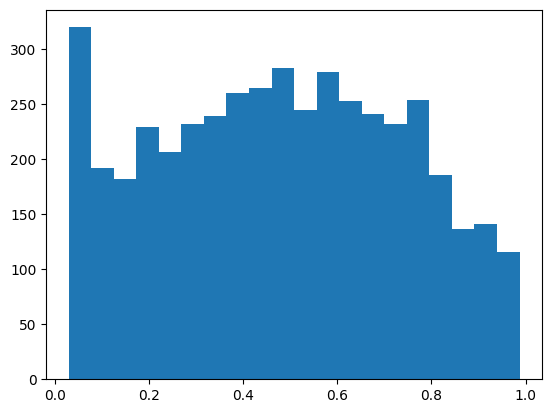

In [18]:
# Valence 
# We can see no outliers and is already scaled between 0 and 1. No prep needed. 
plt.hist(songs['valence'], bins=20)
plt.show()

In [19]:
# Time signature
# 4 unique values - treat as categorical, one hot encode
songs['time_signature'].nunique()

songs['time_signature'] = songs['time_signature'].astype('category')

songs = pd.get_dummies(songs, columns=['time_signature'], drop_first=True)

In [20]:
# Key
# 12 unique values - treat as categorical, one hot encode
songs['key'].nunique()

songs['key'] = songs['key'].astype('category')

songs = pd.get_dummies(songs, columns=['key'], drop_first=True)

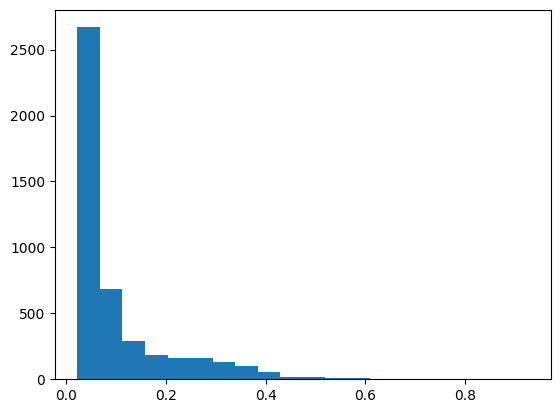

In [21]:
# speechiness
plt.hist(songs['speechiness'], bins=20)
plt.show()

# Can see that most data is close to 0, with long tail and max around 0.6. 
# Use MinMax Scaler to put on 0-1 scale
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
songs['speechiness'] = scaler.fit_transform(songs[['speechiness']])

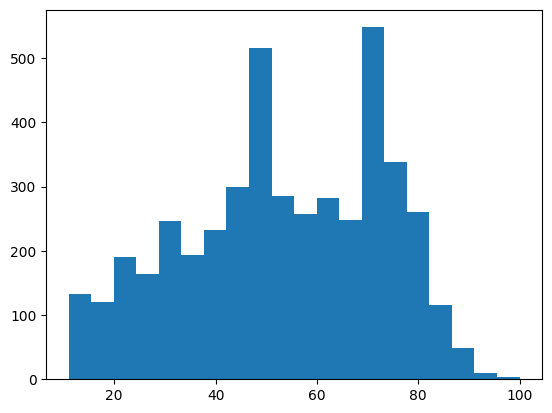

In [22]:
# track_popularity
songs['track_popularity'].isna().sum()

# fill with 0s to represnt missing/unknown. The model will be blind to popularity during training so missing values are not important. 
songs['track_popularity'] = songs['track_popularity'].fillna(0)
songs['track_popularity'].isna().sum()

plt.hist(songs['track_popularity'], bins=20)
plt.show()

# Use MinMaxScaler to scale 
scaler = MinMaxScaler()
songs['track_popularity'] = scaler.fit_transform(songs[['track_popularity']])

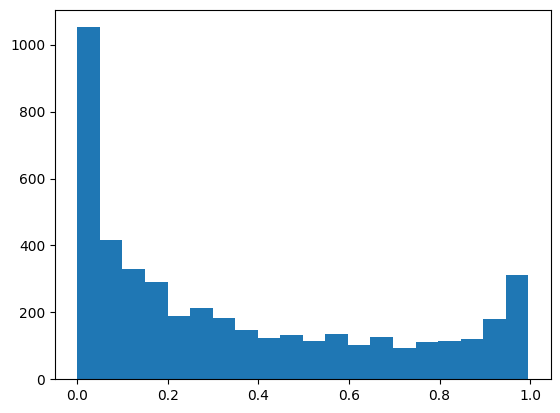

In [23]:
# Make popularity columns on a scale of 0-1
songs['artist_popularity'] = songs['artist_popularity'] / 100
songs['artist_top_track_popularity'] = songs['artist_top_track_popularity'] / 100

# Encode categorical columns to binary values (adds a column per subgenre)
subgenre_dummies = songs['playlist_subgenre'].str.get_dummies(sep=', ')

#Add prefix to keep column names clear
subgenre_dummies = subgenre_dummies.add_prefix('playlist_subgenre_')

#Join back to dataset
songs = pd.concat([songs, subgenre_dummies], axis=1)

#Drop original column
songs = songs.drop(columns=['playlist_subgenre'])


plt.hist(songs['acousticness'], bins=20)
plt.show()

In [24]:
from sklearn.preprocessing import MinMaxScaler

cols_to_scale = ['energy', 'tempo', 'danceability', 'loudness', 'liveness']

scaler = MinMaxScaler()
songs[cols_to_scale] = scaler.fit_transform(songs[cols_to_scale])

# songs = pd.get_dummies(songs, columns=['playlist_genre'], drop_first=True)

# Encode categorical columns to binary values (adds a column per subgenre)
subgenre_dummies = songs['playlist_genre'].str.get_dummies(sep=', ')

#Add prefix to keep column names clear
subgenre_dummies = subgenre_dummies.add_prefix('playlist_genre_')

#Join back to dataset
songs = pd.concat([songs, subgenre_dummies], axis=1)

#Drop original column
songs = songs.drop(columns=['playlist_genre'])


In [25]:
songs['track_id'].nunique()

4493

In [26]:
songs

,track_id,energy,tempo,danceability,loudness,liveness,valence,track_artist,speechiness,track_popularity,track_name,instrumentalness,mode,acousticness,id,artist_popularity,artist_top_track_popularity,time_signature_3.0,time_signature_4.0,time_signature_5.0,key_1.0,key_2.0,key_3.0,key_4.0,key_5.0,key_6.0,key_7.0,key_8.0,key_9.0,key_10.0,key_11.0,playlist_subgenre_80s,playlist_subgenre_90s,playlist_subgenre_academic,playlist_subgenre_african,playlist_subgenre_afro house,playlist_subgenre_afro-latin,playlist_subgenre_alternative,playlist_subgenre_amapiano,playlist_subgenre_american,playlist_subgenre_anime,playlist_subgenre_australian,playlist_subgenre_avant-garde,playlist_subgenre_bedroom,playlist_subgenre_bhangra,playlist_subgenre_bollywood,playlist_subgenre_cajun,playlist_subgenre_carnival,playlist_subgenre_celtic,playlist_subgenre_chill,playlist_subgenre_chinese,playlist_subgenre_choral,playlist_subgenre_cinematic,playlist_subgenre_classic,playlist_subgenre_classical,playlist_subgenre_cumbia,playlist_subgenre_death,playlist_subgenre_deep house,playlist_subgenre_delta,playlist_subgenre_desi,playlist_subgenre_drama,playlist_subgenre_drill,playlist_subgenre_essential,playlist_subgenre_experimental,playlist_subgenre_feel-good,playlist_subgenre_forró,playlist_subgenre_french,playlist_subgenre_funk,playlist_subgenre_fusion,playlist_subgenre_future,playlist_subgenre_future bass,playlist_subgenre_gangster,playlist_subgenre_global,playlist_subgenre_gqom,playlist_subgenre_grime,playlist_subgenre_hardstyle,playlist_subgenre_heavy,playlist_subgenre_hip-hop,playlist_subgenre_indie,playlist_subgenre_indigenous,playlist_subgenre_irish,playlist_subgenre_italo,playlist_subgenre_japanese,playlist_subgenre_jewish,playlist_subgenre_klezmer,playlist_subgenre_latin,playlist_subgenre_mainstream,playlist_subgenre_meditative,playlist_subgenre_melodic,playlist_subgenre_modern,playlist_subgenre_neo-classical,playlist_subgenre_nigerian,playlist_subgenre_noir,playlist_subgenre_nordic,playlist_subgenre_pop,playlist_subgenre_pop punk,playlist_subgenre_post-rock,playlist_subgenre_reggaeton,playlist_subgenre_retro,playlist_subgenre_samba,playlist_subgenre_scandi,playlist_subgenre_smooth,playlist_subgenre_soft,playlist_subgenre_soundtracks,playlist_subgenre_southern,playlist_subgenre_spanish,playlist_subgenre_tango,playlist_subgenre_techno,playlist_subgenre_throat singing,playlist_subgenre_throwback,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_vaporwave,playlist_subgenre_workout,playlist_subgenre_yoga,playlist_genre_afrobeats,playlist_genre_ambient,playlist_genre_arabic,playlist_genre_blues,playlist_genre_brazilian,playlist_genre_cantopop,playlist_genre_classical,playlist_genre_country,playlist_genre_disco,playlist_genre_electronic,playlist_genre_folk,playlist_genre_funk,playlist_genre_gaming,playlist_genre_gospel,playlist_genre_hip-hop,playlist_genre_indian,playlist_genre_indie,playlist_genre_j-pop,playlist_genre_jazz,playlist_genre_k-pop,playlist_genre_korean,playlist_genre_latin,playlist_genre_lofi,playlist_genre_mandopop,playlist_genre_metal,playlist_genre_pop,playlist_genre_punk,playlist_genre_r&b,playlist_genre_reggae,playlist_genre_rock,playlist_genre_soca,playlist_genre_soul,playlist_genre_turkish,playlist_genre_wellness,playlist_genre_world
0,00Coyxt9mTec1acC52qtWa,0.736420,0.329870,0.634822,0.898334,0.083507,0.502,TAEIL,0.009170,0.494382,Starlight,0.000000,1.0,0.078600,00Coyxt9mTec1acC52qtWa,0.00,0.55,False,True,False,False,True,False,False,False,False,False,False,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00DPAwQ3NkWs6PZKNxy7Pi,0.899779,0.433735,0.782632,0.880394,0.168058,0.675,Olamilekan Akamo,0.069716,0.213483,Praise Combo,0.142000,1.0,0.022000,00DPAwQ3NkWs6PZKNxy7Pi,0.00,0.30,False,True,False,False,False,False,Fal

In [27]:
songs.describe()

,energy,tempo,danceability,loudness,liveness,valence,speechiness,track_popularity,instrumentalness,mode,acousticness,artist_popularity,artist_top_track_popularity,playlist_subgenre_80s,playlist_subgenre_90s,playlist_subgenre_academic,playlist_subgenre_african,playlist_subgenre_afro house,playlist_subgenre_afro-latin,playlist_subgenre_alternative,playlist_subgenre_amapiano,playlist_subgenre_american,playlist_subgenre_anime,playlist_subgenre_australian,playlist_subgenre_avant-garde,playlist_subgenre_bedroom,playlist_subgenre_bhangra,playlist_subgenre_bollywood,playlist_subgenre_cajun,playlist_subgenre_carnival,playlist_subgenre_celtic,playlist_subgenre_chill,playlist_subgenre_chinese,playlist_subgenre_choral,playlist_subgenre_cinematic,playlist_subgenre_classic,playlist_subgenre_classical,playlist_subgenre_cumbia,playlist_subgenre_death,playlist_subgenre_deep house,playlist_subgenre_delta,playlist_subgenre_desi,playlist_subgenre_drama,playlist_subgenre_drill,playlist_subgenre_essential,playlist_subgenre_experimental,playlist_subgenre_feel-good,playlist_subgenre_forró,playlist_subgenre_french,playlist_subgenre_funk,playlist_subgenre_fusion,playlist_subgenre_future,playlist_subgenre_future bass,playlist_subgenre_gangster,playlist_subgenre_global,playlist_subgenre_gqom,playlist_subgenre_grime,playlist_subgenre_hardstyle,playlist_subgenre_heavy,playlist_subgenre_hip-hop,playlist_subgenre_indie,playlist_subgenre_indigenous,playlist_subgenre_irish,playlist_subgenre_italo,playlist_subgenre_japanese,playlist_subgenre_jewish,playlist_subgenre_klezmer,playlist_subgenre_latin,playlist_subgenre_mainstream,playlist_subgenre_meditative,playlist_subgenre_melodic,playlist_subgenre_modern,playlist_subgenre_neo-classical,playlist_subgenre_nigerian,playlist_subgenre_noir,playlist_subgenre_nordic,playlist_subgenre_pop,playlist_subgenre_pop punk,playlist_subgenre_post-rock,playlist_subgenre_reggaeton,playlist_subgenre_retro,playlist_subgenre_samba,playlist_subgenre_scandi,playlist_subgenre_smooth,playlist_subgenre_soft,playlist_subgenre_soundtracks,playlist_subgenre_southern,playlist_subgenre_spanish,playlist_subgenre_tango,playlist_subgenre_techno,playlist_subgenre_throat singing,playlist_subgenre_throwback,playlist_subgenre_trap,playlist_subgenre_tropical,playlist_subgenre_vaporwave,playlist_subgenre_workout,playlist_subgenre_yoga,playlist_genre_afrobeats,playlist_genre_ambient,playlist_genre_arabic,playlist_genre_blues,playlist_genre_brazilian,playlist_genre_cantopop,playlist_genre_classical,playlist_genre_country,playlist_genre_disco,playlist_genre_electronic,playlist_genre_folk,playlist_genre_funk,playlist_genre_gaming,playlist_genre_gospel,playlist_genre_hip-hop,playlist_genre_indian,playlist_genre_indie,playlist_genre_j-pop,playlist_genre_jazz,playlist_genre_k-pop,playlist_genre_korean,playlist_genre_latin,playlist_genre_lofi,playlist_genre_mandopop,playlist_genre_metal,playlist_genre_pop,playlist_genre_punk,playlist_genre_r&b,playlist_genre_reggae,playlist_genre_rock,playlist_genre_soca,playlist_genre_soul,playlist_genre_turkish,playlist_genre_wellness,playlist_genre_world
count,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.00000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493.000000,4493

In [28]:
# Save cleaned dataset
songs.to_csv("cleaned_data_songs.csv", index=False)